# 00. Prepare the Wine Review Dataset (run this notebook first)

Puts the **original wine corpus** - the dataset the whole BAMIC project started from -
into the exact same benchmark framework as SST-2 / IMDB / Yelp, so every model
notebook (01-06) reads identical splits and writes the identical `final_metrics.csv`
format used by all the comparison tables.

**Source.** `AMIC project/data/05_16_9reviewer.xlsx` - the 9-reviewer Wine Spectator
extract already in your Drive (141,904 reviews, columns `Clean_desc` and `rating`).
No download needed.

**Label rule** (same as the original notebooks): a review is positive when
`rating >= 90`. This makes the dataset **imbalanced (~34% positive)** - the one
structural difference from the other benchmarks; the BAMIC / CNN / BiLSTM losses
use `pos_weight` to compensate, and F1/AUC matter more than raw accuracy here.

**Splits.** The full corpus (141,904 reviews) made the transformer baselines take
~40 minutes PER EPOCH, so we use a **seeded stratified subsample** that mirrors the
Yelp/IMDB benchmark scale: **train 25,000 / valid 3,000 / test 10,000** (seed
20260526, positive rate preserved at 0.342 in every split). Every model trains on
the same subsample, so the comparison stays internally fair; the June full-data
BAMIC run (test acc 0.8620) remains the original-corpus reference point.

**Text.** We keep the FULL review text including the trailing metadata
("Drink now. 5,000 cases made.") - notebook 01 penalizes that boilerplate via
lambda_B exactly like the published wine runs, and the baselines see the same text.

**Outputs** (`AMIC project/wine_benchmark/data/`): `wine_train.csv`,
`wine_valid.csv`, `wine_test.csv` with columns `text`, `y`, `rating`.

Run order: **00 -> 01 (BAMIC) -> 02 -> 03 -> 04 -> 05 -> 06.**

In [9]:
# ================================================================
# 0. Check the Colab GPU
# ================================================================

# Ask the Colab runtime which GPU we were given.
gpu_info = !nvidia-smi
# Join the command output lines into one printable string.
gpu_info = '\n'.join(gpu_info)
# If the command failed, we are not connected to a GPU runtime.
if gpu_info.find('failed') >= 0:
    print('Not connected to a GPU. In Colab: Runtime -> Change runtime type -> T4 GPU.')
else:
    print(gpu_info)

Tue Aug  4 04:31:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   33C    P0             60W /  400W |   12114MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [10]:
# ================================================================
# 1. Check the Colab RAM
# ================================================================

# psutil reports how much system memory this runtime has.
import psutil
# Convert bytes to gigabytes for a readable number.
ram_gb = psutil.virtual_memory().total / 1e9
# Print the available RAM so we know which runtime type we received.
print('Your runtime has {:.1f} gigabytes of available RAM'.format(ram_gb))

Your runtime has 179.4 gigabytes of available RAM


In [11]:
# ================================================================
# 2. Basic imports and reproducibility
# ================================================================

# pathlib gives clean, operating-system-safe file paths.
from pathlib import Path

# random controls Python-level randomness.
import random

# re normalizes whitespace during cleaning.
import re

# numpy handles numeric arrays.
import numpy as np

# pandas reads the Excel source and writes the CSV splits.
import pandas as pd

# train_test_split creates the reproducible stratified splits.
from sklearn.model_selection import train_test_split

# This seed keeps the splits identical every time (same seed as all our notebooks).
SEED = 20260526

# Seed Python's random module.
random.seed(SEED)

# Seed NumPy's random generator.
np.random.seed(SEED)

In [12]:
# ================================================================
# 3. Mount Google Drive and define project paths
# ================================================================

# Mount Google Drive so Colab can read and write project files.
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive mounted.')

# This is the same Google Drive project folder used by the wine and SST-2 notebooks.
PROJECT_DIR = Path('/content/drive/MyDrive/AMIC project')

# All wine benchmark files live inside this subfolder.
BENCH_DIR = PROJECT_DIR / 'wine_benchmark'

# The shared, prepared wine splits are stored here by notebook 00.
DATA_DIR = BENCH_DIR / 'data'

# This notebook writes all of its results into its own output folder.
EXPERIMENT_NAME = 'wine_data_prep'
OUTPUT_DIR = DATA_DIR  # the prepared CSVs ARE this notebook's output

# Create the output folder if it does not exist yet.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Print the paths so we can verify them before loading data.
print('DATA_DIR  :', DATA_DIR)
print('OUTPUT_DIR:', OUTPUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted.
DATA_DIR  : /content/drive/MyDrive/AMIC project/wine_benchmark/data
OUTPUT_DIR: /content/drive/MyDrive/AMIC project/wine_benchmark/data


In [13]:
# ================================================================
# 4. Load the wine Excel source from Drive
# ================================================================

# The 9-reviewer Wine Spectator extract used by all the original BAMIC wine runs.
SOURCE_XLSX = PROJECT_DIR / 'data' / '05_16_9reviewer.xlsx'

# Same positive cutoff as the original notebooks: 90+ points = positive.
POSITIVE_RATING_CUTOFF = 90

# Skip the slow Excel read if the prepared CSVs already exist in Drive.
# Also verify the row count: older full-size splits (127,713 train rows) must be
# regenerated at the new subsample size, not silently reused.
N_TRAIN, N_VALID, N_TEST = 25000, 3000, 10000
already_prepared = all((DATA_DIR / name).exists()
                       for name in ['wine_train.csv', 'wine_valid.csv', 'wine_test.csv'])
if already_prepared:
    n_existing = len(pd.read_csv(DATA_DIR / 'wine_train.csv', usecols=['y']))
    if n_existing != N_TRAIN:
        print(f'Existing wine_train.csv has {n_existing:,} rows (expected {N_TRAIN:,}) - regenerating.')
        already_prepared = False
print('Prepared CSVs already in Drive (at the right size):', already_prepared)

if not already_prepared:
    # Stop early with a clear message if the source file is missing.
    if not SOURCE_XLSX.exists():
        raise FileNotFoundError(f'Missing {SOURCE_XLSX} - check the Drive data folder.')
    # Read the Excel file (13 MB, ~1-2 minutes with openpyxl).
    print('Loading', SOURCE_XLSX, '...')
    df = pd.read_excel(SOURCE_XLSX)
    # Keep only the two columns the benchmark needs, plus the raw rating.
    df = df[['Clean_desc', 'rating']].rename(columns={'Clean_desc': 'text'})
    # Normalize whitespace but KEEP the original casing and the trailing metadata
    # (notebook 01 penalizes the metadata; the baselines see the same full text).
    df['text'] = df['text'].astype(str).map(lambda s: re.sub(r'\s+', ' ', s).strip())
    # Coerce the rating to numeric and drop any unparseable rows.
    df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
    df = df.dropna(subset=['rating']).reset_index(drop=True)
    # Binary label: 90+ points is positive (the original label rule).
    df['y'] = (df['rating'] >= POSITIVE_RATING_CUTOFF).astype(int)
    # Print the size and the positive rate (expect ~142k rows, ~0.34 positive).
    print('rows:', len(df), '| positive rate:', round(df['y'].mean(), 4))

Existing wine_train.csv has 127,713 rows (expected 25,000) - regenerating.
Prepared CSVs already in Drive (at the right size): False
Loading /content/drive/MyDrive/AMIC project/data/05_16_9reviewer.xlsx ...
rows: 141904 | positive rate: 0.342


In [14]:
# ================================================================
# 5. Seeded stratified subsample -> train 25,000 / valid 3,000 / test 10,000
# ================================================================

# Why a subsample: the full 141,904-review corpus made BERT/RoBERTa take ~40 min
# PER EPOCH on a T4. These sizes mirror the Yelp/IMDB benchmarks, cutting the
# transformer epochs to ~8-10 min while leaving every model plenty of data.
# stratify=y preserves the natural 34/66 imbalance in every split (we do NOT
# rebalance: the rating>=90 label rule stays exactly as in the original work).

if already_prepared:
    # The CSVs are already in Drive, so just load them back for the checks below.
    train_df = pd.read_csv(DATA_DIR / 'wine_train.csv')
    valid_df = pd.read_csv(DATA_DIR / 'wine_valid.csv')
    test_df = pd.read_csv(DATA_DIR / 'wine_test.csv')
else:
    # Draw the 38,000-review subsample from the full corpus, stratified by label.
    subset, _ = train_test_split(
        df, train_size=N_TRAIN + N_VALID + N_TEST, random_state=SEED, stratify=df['y'])
    # Carve the training split out of the subsample.
    train_df, rest = train_test_split(
        subset, train_size=N_TRAIN, random_state=SEED, stratify=subset['y'])
    # Split the remainder into validation and test.
    valid_df, test_df = train_test_split(
        rest, train_size=N_VALID, random_state=SEED, stratify=rest['y'])
    # Clean row indices for saving.
    train_df = train_df.reset_index(drop=True)
    valid_df = valid_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)

# Print the final sizes and label balance of each split.
# Expected: train (25000, 3), valid (3000, 3), test (10000, 3), positive rate ~0.342.
print('train:', train_df.shape, '| positive rate:', round(train_df['y'].mean(), 4))
print('valid:', valid_df.shape, '| positive rate:', round(valid_df['y'].mean(), 4))
print('test :', test_df.shape, '| positive rate:', round(test_df['y'].mean(), 4))

train: (25000, 3) | positive rate: 0.342
valid: (3000, 3) | positive rate: 0.342
test : (10000, 3) | positive rate: 0.342


count    25000.000000
mean        31.828640
std          8.516432
min          8.000000
25%         26.000000
50%         31.000000
75%         37.000000
max         85.000000
Name: text, dtype: float64
Share of train reviews with <= 100 tokens: 1.0
Reviews mentioning case production: 0.945
Reviews with drinking-window phrases: 0.983


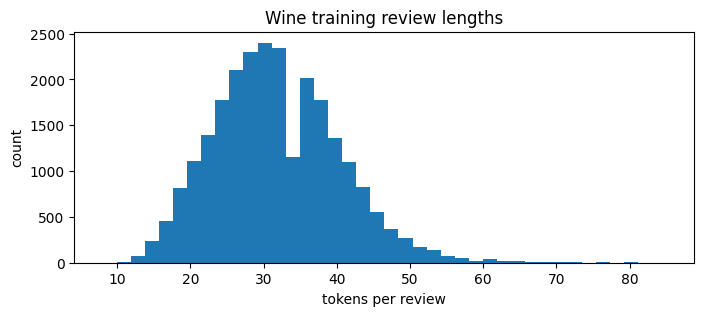

In [15]:
# ================================================================
# 6. Review lengths and a boilerplate check
# ================================================================

# matplotlib draws the histogram.
import matplotlib.pyplot as plt

# Count whitespace-separated tokens per training review.
lengths = train_df['text'].str.split().str.len()

# Print summary statistics (expect mean ~32, everything <= 100).
print(lengths.describe())
print('Share of train reviews with <= 100 tokens:', round((lengths <= 100).mean(), 4))

# Quick look at how common the trailing metadata is (notebook 01 penalizes it).
has_cases = train_df['text'].str.contains(r'cases (?:made|imported)', case=False, regex=True)
has_drink = train_df['text'].str.contains(r'drink now|drink through|best from', case=False, regex=True)
print('Reviews mentioning case production:', round(has_cases.mean(), 3))
print('Reviews with drinking-window phrases:', round(has_drink.mean(), 3))

# Draw a simple histogram of review lengths.
plt.figure(figsize=(8, 3))
plt.hist(lengths, bins=40)
plt.xlabel('tokens per review')
plt.ylabel('count')
plt.title('Wine training review lengths')
plt.show()

In [16]:
# ================================================================
# 7. Save the shared splits to Drive
# ================================================================

# Every model notebook will read these three files, so we save them once here.
train_df[['text', 'y', 'rating']].to_csv(DATA_DIR / 'wine_train.csv', index=False)
valid_df[['text', 'y', 'rating']].to_csv(DATA_DIR / 'wine_valid.csv', index=False)
test_df[['text', 'y', 'rating']].to_csv(DATA_DIR / 'wine_test.csv', index=False)

# Confirm the files now exist in Drive.
for name in ['wine_train.csv', 'wine_valid.csv', 'wine_test.csv']:
    path = DATA_DIR / name
    print(path, '| exists:', path.exists(), '| rows:', len(pd.read_csv(path)))

/content/drive/MyDrive/AMIC project/wine_benchmark/data/wine_train.csv | exists: True | rows: 25000
/content/drive/MyDrive/AMIC project/wine_benchmark/data/wine_valid.csv | exists: True | rows: 3000
/content/drive/MyDrive/AMIC project/wine_benchmark/data/wine_test.csv | exists: True | rows: 10000


**Done.** The three shared splits are saved. You can now run any model notebook (01-06).